# VK HR Tek One: оценка аудитории и выручки HR-платформы до 2027 года

Ноутбук с расчётами к концепции единой HR-платформы VK. Здесь считаются:

1. рынок HRTech в России до 2027 года;
2. TAM, SAM и SOM в компаниях и в пользователях;
3. MAU и DAU платформы по трём группам пользователей;
4. выручка по источникам монетизации на 2025–2027 годы;
5. три сценария и чувствительность к ключевым допущениям.

**Опорные данные из открытых источников**

| Показатель | Значение | Источник |
|---|---|---|
| Рынок HRTech (выручка топ-компаний), 2025 | 94 млрд ₽, +9,3% | Smart Ranking, апрель 2026 |
| Рынок HRTech, I полугодие 2026 | 45 млрд ₽, +8% | Smart Ranking, август 2026 |
| Выручка HeadHunter, 2025 | 41,2 млрд ₽ | отчётность hh.ru |
| Платящие клиенты hh.ru, II кв. 2025 | 284 357, −15,3% | отчётность hh.ru |
| Авито Работа | 17,4 млн пользователей в месяц, 370 тыс. работодателей | Авито, февраль 2026 |
| Субъекты МСП | 6,6 млн, 81,8% всех ЮЛ и ИП | ФНС, июль 2026 |
| hh.индекс, январь 2026 | 9,6 резюме на вакансию; 1,2 млн вакансий, 21 млн резюме | hh.ru |
| Среднее время закрытия вакансии | 38 дней | Inc. Russia |
| Стоимость найма и адаптации | около 250 тыс. ₽ | Inc. Russia |
| ИИ в подборе | 5% компаний | Inc. Russia |
| VK Tech, 2025 | 18,8 млрд ₽ выручки, 31,9 тыс. клиентов | VK |
| VK HR Tek | 500+ клиентов из 20+ отраслей | hrtek.vk.ru |
| ВКонтакте, II кв. 2026 | MAU 94,3 млн, DAU 65,2 млн | VK |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.1f}'.replace(',', ' '))
YEARS = [2025, 2026, 2027]
SEG = ['Микро (1–15)', 'Малые (16–100)', 'Средние (101–250)', 'Крупные (250+)']

## 1. Рынок HRTech

База — 94 млрд ₽ в 2025 году. На 2026 год берём фактический темп первого полугодия (+8%), на 2027 год — +9%: рынок труда остаётся перекошенным в сторону работодателя, но бюджеты на автоматизацию и удержание растут быстрее найма.

In [2]:
market = pd.Series({2025: 94.0}, name='Рынок HRTech, млрд ₽')
market[2026] = market[2025] * 1.08
market[2027] = market[2026] * 1.09
market.round(1)

2025    94.0
2026   101.5
2027   110.7
Name: Рынок HRTech, млрд ₽, dtype: float64

## 2. TAM, SAM, SOM

**Единица счёта — компания-работодатель и её пользователи.** Бюджетный сектор исключён: там закупки идут через тендеры и государственные системы.

* **TAM** — все коммерческие работодатели с наёмными сотрудниками. Около 2,18 млн в 2025 году (из 8,1 млн действующих ЮЛ и ИП), рост 1,5% в год.
* **SAM** — те, кого платформа реально может обслужить: микробизнес, который нанимает хотя бы раз в год и работает с цифровыми каналами (35%), 80% малых, 90% средних и 70% крупных компаний (часть крупных заперта в SAP и собственных разработках).
* **SOM** — компании, которые активно пользуются платформой. База 2025 года — 500 клиентов VK HR Tek и работодатели, публикующие вакансии в разделе «Работа» ВКонтакте.

In [3]:
universe_2025 = pd.DataFrame({
    'companies': [1_950_000, 200_000, 20_000, 14_000],
    'avg_staff': [5, 38, 160, 1_600],
    'sam_share': [0.35, 0.80, 0.90, 0.70],
}, index=SEG)

growth = 1.015
rows = []
for y in YEARS:
    k = growth ** (y - 2025)
    comp = universe_2025['companies'] * k
    rows.append({'Год': y,
                 'TAM, тыс. компаний': comp.sum() / 1e3,
                 'TAM, млн сотрудников': (comp * universe_2025['avg_staff']).sum() / 1e6,
                 'SAM, тыс. компаний': (comp * universe_2025['sam_share']).sum() / 1e3,
                 'SAM, млн сотрудников': (comp * universe_2025['sam_share'] * universe_2025['avg_staff']).sum() / 1e6})
tam_sam = pd.DataFrame(rows).set_index('Год')
tam_sam

,"TAM, тыс. компаний","TAM, млн сотрудников","SAM, тыс. компаний","SAM, млн сотрудников"
Год,,,,
2025,2 184.0,43.0,870.3,28.1
2026,2 216.8,43.6,883.4,28.5
2027,2 250.0,44.2,896.6,28.9


### Активные компании на платформе (SOM, базовый сценарий)

Рост 2026–2027 годов опирается на три вещи: бесплатную публикацию вакансий для микро- и малого бизнеса во ВКонтакте, продажу модуля «Найм» действующим клиентам VK HR Tek и кросс-продажи клиентам VK Tech (31,9 тыс. компаний, в первую очередь пользователям VK WorkSpace).

In [4]:
som = pd.DataFrame({
    2025: [12_000, 3_000, 180, 320],
    2026: [20_000, 5_200, 700, 430],
    2027: [38_000, 9_500, 1_600, 620],
}, index=SEG)

sam_2027 = universe_2025['companies'] * growth**2 * universe_2025['sam_share']
som_view = som.copy()
som_view['Доля SAM 2027'] = (som[2027] / sam_2027 * 100).round(1).astype(str) + '%'
som_view.loc['Итого'] = list(som.sum()) + [f'{som[2027].sum() / sam_2027.sum() * 100:.1f}%']
som_view

,2025,2026,2027,Доля SAM 2027
Микро (1–15),12000,20000,38000,5.4%
Малые (16–100),3000,5200,9500,5.8%
Средние (101–250),180,700,1600,8.6%
Крупные (250+),320,430,620,6.1%
Итого,15500,26330,49720,5.5%


## 3. MAU и DAU

Пользователей три типа:

1. **HR-сторона** — HR-специалисты, рекрутеры, нанимающие менеджеры. Работают в системе каждый день.
2. **Сотрудники клиентов** — подписывают документы в КЭДО, оформляют отпуска и командировки, читают корпоративный портал.
3. **Кандидаты** — ищут работу и откликаются в разделе «Работа» ВКонтакте и через чат-ботов. Бесплатная сторона двустороннего рынка.

In [5]:
hr_users = pd.Series([1.3, 3, 9, 55], index=SEG)          # HR-пользователей на компанию
emp_adopt = pd.DataFrame({2025: [0.02, 0.10, 0.50, 0.70],   # доля компаний с модулями для сотрудников
                          2026: [0.05, 0.20, 0.52, 0.72],
                          2027: [0.10, 0.30, 0.55, 0.75]}, index=SEG)
emp_active = 0.60                                             # доля сотрудников, активных в месяц
candidates_mau = pd.Series({2025: 2.1, 2026: 3.2, 2027: 5.5}) # млн, кандидатская сторона
stickiness = {'HR': 0.55, 'Сотрудники': 0.12, 'Кандидаты': 0.18}

mau = pd.DataFrame(index=YEARS)
mau['HR'] = [(som[y] * hr_users).sum() / 1e6 for y in YEARS]
mau['Сотрудники'] = [(som[y] * emp_adopt[y] * universe_2025['avg_staff'] * emp_active).sum() / 1e6 for y in YEARS]
mau['Кандидаты'] = candidates_mau.values
mau['MAU всего'] = mau[['HR', 'Сотрудники', 'Кандидаты']].sum(axis=1)

dau = pd.DataFrame(index=YEARS)
for k, v in stickiness.items():
    dau[k] = mau[k] * v
dau['DAU всего'] = dau.sum(axis=1)
dau['DAU/MAU'] = dau['DAU всего'] / mau['MAU всего']

print('MAU, млн'); display(mau.round(2))
print('DAU, млн'); display(dau.round(2))

MAU, млн


,HR,Сотрудники,Кандидаты,MAU всего
2025,0.0,0.2,2.1,2.4
2026,0.1,0.4,3.2,3.6
2027,0.1,0.6,5.5,6.2


DAU, млн


,HR,Сотрудники,Кандидаты,DAU всего,DAU/MAU
2025,0.0,0.0,0.4,0.4,0.2
2026,0.0,0.0,0.6,0.7,0.2
2027,0.1,0.1,1.0,1.1,0.2


**Проверка на здравый смысл.** 5,5 млн кандидатов в месяц — это 5,8% месячной аудитории ВКонтакте (94,3 млн) и меньше трети аудитории Авито Работы (17,4 млн). 0,6 млн активных сотрудников в B2B-модулях — это 60% от 1 млн работников, чьи работодатели подключили КЭДО и портал; основная масса приходится на 620 крупных клиентов.

## 4. Выручка

Цены индексируются на 8% в год от уровня 2025 года. Потоки выручки:

| Поток | Кто платит | Цена 2025 |
|---|---|---|
| Подписка HR-ядро (КЭДО, портал, отпуска, командировки) | за сотрудника в месяц | 100 / 140 / 175 ₽ (крупные / средние / малые); микробизнес — тариф 920 ₽ в месяц |
| Модуль «Найм» (ATS + ИИ) | за место рекрутера в месяц | 3 700 / 3 250 / 2 700 ₽ |
| Публикация и продвижение вакансий | за вакансию на 30 дней | 1 380 ₽, первая вакансия бесплатно |
| Рекрутинговые кампании в VK Рекламе | рекламный бюджет | средний годовой бюджет по сегменту |
| ИИ-скрининг и ИИ-интервью | за обработанного кандидата | 9–14 ₽ |
| Внедрение и интеграции | разово за проект | 1,1 млн ₽ крупные, 140 тыс. ₽ средние |
| Брендинг работодателя | подписка на страницу | 1 760 ₽ в месяц |

In [6]:
idx = {y: 1.08 ** (y - 2025) for y in YEARS}

price_seat = pd.Series([0, 175, 140, 100], index=SEG)   # ₽ за сотрудника в мес., цены 2025
micro_plan = 920                                         # ₽ в мес., тариф для микробизнеса
ats_seats = pd.Series([0, 1.5, 3, 12], index=SEG)
ats_share = pd.DataFrame({2025: [0, 0.05, 0.20, 0.35], 2026: [0, 0.15, 0.35, 0.50], 2027: [0, 0.25, 0.50, 0.60]}, index=SEG)
ats_price = pd.Series([0, 2_700, 3_250, 3_700], index=SEG)
post_share = pd.Series([0.30, 0.60, 0.80, 0.90], index=SEG)
post_per_year = pd.Series([4, 14, 40, 150], index=SEG)
post_price = 1_380
ads_share = pd.Series([0.03, 0.20, 0.40, 0.60], index=SEG)
ads_budget = pd.Series([26_000, 52_000, 260_000, 1_030_000], index=SEG)
ai_share = pd.DataFrame({2025: [0, 0, 0, 0], 2026: [0, 0.08, 0.15, 0.20], 2027: [0, 0.20, 0.40, 0.50]}, index=SEG)
ai_volume = pd.Series([0, 600, 3_000, 25_000], index=SEG)
ai_price = pd.Series([0, 14, 11, 9], index=SEG)
impl_price = pd.Series([0, 0, 140_000, 1_100_000], index=SEG)
brand_share = pd.Series([0, 0.10, 0.30, 0.60], index=SEG)
brand_price = 1_760

def revenue(som, k_price=1.0):
    out = {}
    prev = None
    for y in YEARS:
        p = idx[y] * k_price
        n = som[y]
        adopt = n * emp_adopt[y]
        core = (adopt * universe_2025['avg_staff'] * price_seat * 12 * p)
        core[SEG[0]] = adopt[SEG[0]] * micro_plan * 12 * p
        new = (n - prev).clip(lower=0) if prev is not None else n * 0.25
        out[y] = {
            'Подписка HR-ядро': core.sum(),
            'Модуль «Найм» (ATS)': (n * ats_share[y] * ats_seats * ats_price * 12 * p).sum(),
            'Публикация и продвижение вакансий': (n * post_share * post_per_year * post_price * p).sum(),
            'Рекрутинговая реклама в VK Рекламе': (n * ads_share * ads_budget * p).sum(),
            'ИИ-скрининг и ИИ-интервью': (n * ai_share[y] * ai_volume * ai_price * p).sum(),
            'Внедрение и интеграции': (new * impl_price * p).sum(),
            'Брендинг работодателя': (n * brand_share * brand_price * 12 * p).sum(),
        }
        prev = n
    df = pd.DataFrame(out) / 1e6
    df.loc['Итого'] = df.sum()
    return df

rev_base = revenue(som)
rev_base.round(0)

,2025,2026,2027
Подписка HR-ядро,481.0,849.0,1 631.0
Модуль «Найм» (ATS),71.0,196.0,475.0
Публикация и продвижение вакансий,122.0,221.0,419.0
Рекрутинговая реклама в VK Рекламе,257.0,441.0,791.0
ИИ-скрининг и ИИ-интервью,0.0,28.0,125.0
Внедрение и интеграции,94.0,209.0,391.0
Брендинг работодателя,12.0,23.0,44.0
Итого,1 037.0,1 967.0,3 876.0


In [7]:
share = rev_base.loc['Итого'] / (market * 1000) * 100
arpa = rev_base.loc['Итого'] * 1e6 / som.sum() / 1e3
pd.DataFrame({'Выручка, млн ₽': rev_base.loc['Итого'],
              'Доля рынка HRTech, %': share,
              'Активных компаний': som.sum(),
              'Выручка на компанию, тыс. ₽': arpa}).round(1)

,"Выручка, млн ₽","Доля рынка HRTech, %",Активных компаний,"Выручка на компанию, тыс. ₽"
2025,1 037.1,1.1,15500,66.9
2026,1 966.7,1.9,26330,74.7
2027,3 876.0,3.5,49720,78.0


## 5. Сценарии

* **Пессимистичный** — клиентов на 40% меньше, цены на 10% ниже: рынок найма продолжает сжиматься, VK Tech не удаётся продать «Найм» действующим клиентам.
* **Оптимистичный** — клиентов на 40% больше: вход в раздел «Работа» из профиля ВКонтакте и мессенджера MAX, быстрая интеграция с 1С:ЗУП.

In [8]:
scen = {}
for name, k_cnt, k_pr, k_cand in [('Пессимистичный', 0.6, 0.9, 0.6), ('Базовый', 1.0, 1.0, 1.0), ('Оптимистичный', 1.4, 1.0, 1.4)]:
    s = som.copy(); s[2026] = som[2025] + (som[2026] - som[2025]) * k_cnt; s[2027] = som[2025] + (som[2027] - som[2025]) * k_cnt
    r = revenue(s, k_pr).loc['Итого', 2027]
    m_hr = (s[2027] * hr_users).sum() / 1e6
    m_emp = (s[2027] * emp_adopt[2027] * universe_2025['avg_staff'] * emp_active).sum() / 1e6
    m_c = 2.1 + (5.5 - 2.1) * k_cand
    d = m_hr * 0.55 + m_emp * 0.12 + m_c * 0.18
    scen[name] = {'Активных компаний 2027': s[2027].sum(), 'MAU 2027, млн': m_hr + m_emp + m_c, 'DAU 2027, млн': d, 'Выручка 2027, млн ₽': r}
scen = pd.DataFrame(scen).T
scen.round(2)

,Активных компаний 2027,"MAU 2027, млн","DAU 2027, млн","Выручка 2027, млн ₽"
Пессимистичный,36 032.0,4.7,0.8,2 578.4
Базовый,49 720.0,6.2,1.1,3 876.0
Оптимистичный,63 408.0,7.8,1.4,4 887.1


## 6. Чувствительность базового сценария 2027 года

Меняем каждое допущение на ±20% при прочих равных и смотрим, как двигается выручка.

In [9]:
base_total = rev_base.loc['Итого', 2027]
def tornado():
    res = {}
    g = globals()
    for label, var in [('Число клиентов', 'som'), ('Цена подписки HR-ядра', 'price_seat'),
                       ('Бюджеты на рекрутинговую рекламу', 'ads_budget'), ('Цена места ATS', 'ats_price'),
                       ('Цена публикации вакансии', 'post_price')]:
        orig = g[var]
        vals = []
        for k in (0.8, 1.2):
            g[var] = orig * k
            vals.append(revenue(g['som']).loc['Итого', 2027] - base_total)
            g[var] = orig
        res[label] = vals
    return pd.DataFrame(res, index=['−20%', '+20%']).T
sens = tornado()
sens.round(0)

,−20%,+20%
Число клиентов,-775.0,775.0
Цена подписки HR-ядра,-317.0,317.0
Бюджеты на рекрутинговую рекламу,-158.0,158.0
Цена места ATS,-95.0,95.0
Цена публикации вакансии,-84.0,84.0


## 7. Графики

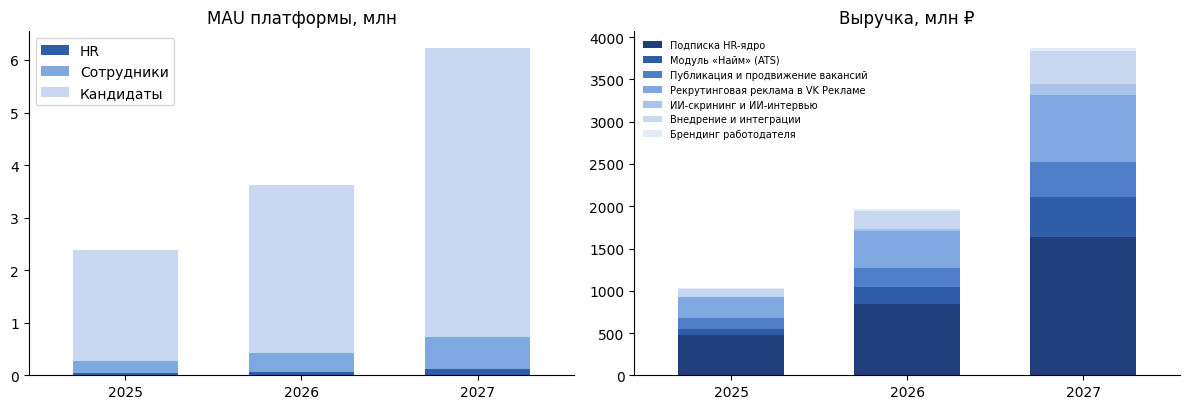

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
mau[['HR', 'Сотрудники', 'Кандидаты']].plot(kind='bar', stacked=True, ax=ax[0], color=['#2F5DA8', '#7FA7E0', '#C9D8F0'], width=0.6)
ax[0].set_title('MAU платформы, млн'); ax[0].set_xlabel(''); ax[0].tick_params(axis='x', rotation=0)
ax[0].spines[['top', 'right']].set_visible(False)
r = rev_base.drop('Итого')
r.T.plot(kind='bar', stacked=True, ax=ax[1], width=0.6,
         color=['#1F3F7A', '#2F5DA8', '#4F7FC8', '#7FA7E0', '#A9C4EA', '#C9D8F0', '#E4ECF8'])
ax[1].set_title('Выручка, млн ₽'); ax[1].set_xlabel(''); ax[1].tick_params(axis='x', rotation=0)
ax[1].legend(fontsize=7, frameon=False, loc='upper left'); ax[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig('charts.png', dpi=160); plt.show()

In [11]:
# выгрузка таблиц для отчёта
import json
export = {'market': market.round(1).to_dict(), 'tam_sam': tam_sam.round(2).to_dict(orient='index'),
          'som': som.to_dict(), 'mau': mau.round(3).to_dict(orient='index'), 'dau': dau.round(3).to_dict(orient='index'),
          'rev': rev_base.round(1).to_dict(), 'scen': scen.round(3).to_dict(orient='index'), 'sens': sens.round(1).to_dict(orient='index'),
          'share': share.round(2).to_dict(), 'arpa': arpa.round(1).to_dict()}
json.dump(export, open('model_output.json', 'w'), ensure_ascii=False, indent=1, default=float)
print('ok')

ok


## Выводы

* К 2027 году платформа может выйти примерно на 50 тыс. активных компаний, 6,2 млн MAU и 1,1 млн DAU. Большая часть MAU — кандидаты, большая часть денег — B2B-подписка.
* Базовая выручка 2027 года — около 3,9 млрд ₽, или 3,5% рынка HRTech. Для сравнения, у hh.ru 41,2 млрд ₽ и две трети рынка.
* Сильнее всего результат зависит от числа клиентов и цены HR-ядра. Рекламные бюджеты на найм — третий по значимости фактор, и именно здесь у VK нет конкурентов с сопоставимым охватом.